# PCA Exemplars: What is Encoded in Effective Dimensions?

This notebook investigates what semantic factors are encoded in the principal components of vision foundation model representations, particularly in extreme intensity bins (Cat 5).

## Method: Top/Bottom-K Exemplars per PC

For each principal component:
1. Compute PC scores for all images
2. Find images with highest/lowest scores
3. Visualize and interpret the semantic factor

**Key Question:** What visual patterns do the PCs capture? Are they label-relevant (e.g., eye structure, convection symmetry) or nuisance factors (e.g., sensor artifacts, cloud texture)?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datasets import load_from_disk
from sklearn.decomposition import PCA
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## Configuration

In [28]:
# Models to analyze
MODELS_TO_ANALYZE = [
    {
        "name": "DINOv3",
        "feature_dataset": "/nfs/scistore19/locatgrp/dyao/DATA/cyclones/image_features/features_dinov3-base",
    }
]

# Raw image dataset (for visualization)
RAW_DATASET_PATH = "/nfs/scistore19/locatgrp/dyao/DATA/cyclones/dataset_hf"

# Number of PCs to analyze
N_PCS_TO_ANALYZE = 1

# Number of exemplars per extreme
K_EXEMPLARS = 4

FEATURE_TYPE = 'cls' # 'cls' or 'spatial_mean'

# Pressure bins
PRESSURE_BINS = [
    (0, 920, "Cat 5 (<920)"),
    (920, 945, "Cat 4 (920-945)"),
    (945, 965, "Cat 3 (945-965)"),
    (965, 980, "Cat 2 (965-980)"),
    (980, 1000, "Cat 1 (980-1000)"),
    (1000, 1020, "TS/TD (1000-1020)"),
]

CAT5_PRESSURE_THRESHOLD = 980
# STRUCTURAL_THRESHOLD = 980 # Pressure threshold to form eye structure

In [3]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,  # TrueType (Type 1 compatible)
    'ps.fonttype': 42,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'grid.linewidth': 0.5,
})

## Step 1: Load Aligned Features and Images

**Critical:** `X[i]` must correspond to `images[i]` (same ordering).

In [4]:
def load_features_and_images(feature_dataset_path: Path, raw_dataset_path: Path, split='test'):
    """
    Load features and store indices for lazy image loading.
    
    Returns:
        X: features array (N, D)
        image_indices: list of (cyclone_idx, frame_idx) tuples for lazy loading
        pressure: pressure values (N,)
        wind: wind values (N,)
        cyclone_ids: cyclone identifiers for each frame
        raw_dataset: the raw dataset (kept for lazy image access)
    """
    print(f"Loading features from {feature_dataset_path}...")
    feature_dataset = load_from_disk(str(feature_dataset_path))
    
    print(f"Loading raw images from {raw_dataset_path}...")
    raw_dataset = load_from_disk(str(raw_dataset_path))
    
    if split not in feature_dataset or split not in raw_dataset:
        raise ValueError(f"Split '{split}' not found in datasets")
    
    feature_data = feature_dataset[split]
    raw_data = raw_dataset[split]
    
    # Verify alignment: same number of cyclones
    assert len(feature_data) == len(raw_data), "Feature and raw datasets have different number of cyclones!"
    
    all_features = []
    all_image_indices = []  # Store (cyclone_idx, frame_idx) for lazy loading
    all_pressure = []
    all_wind = []
    all_cyclone_ids = []
    
    print(f"Extracting {split} data ({len(feature_data)} cyclones)...")
    
    for idx in tqdm(range(len(feature_data)), desc=f"Loading {split}"):
        feat_example = feature_data[idx]
        
        mask = np.asarray(feat_example['frame_valid_mask']).astype(bool)  # (T,)
        
        features = np.array(feat_example['features'][FEATURE_TYPE])[mask]  # (T, D)
        pressure = np.array(feat_example['pressure'])[mask]  # (T,)
        wind = np.array(feat_example['wind'])[mask]  # (T,)        
        # Get cyclone ID if available
        cyclone_id = feat_example.get('cyclone_id', f'cyclone_{idx}')
        
        T = len(pressure)
        
        all_features.extend(features)
        all_image_indices.extend([(idx, t) for t in range(T)])
        all_pressure.extend(pressure)
        all_wind.extend(wind)
        all_cyclone_ids.extend([cyclone_id] * T)
    
    X = np.array(all_features)
    pressure_arr = np.array(all_pressure)
    wind_arr = np.array(all_wind)
    
    print(f"Loaded {len(X):,} frames with {X.shape[1]} features")
    print(f"Images will be loaded lazily (not stored in RAM)")
    
    return X, all_image_indices, pressure_arr, wind_arr, all_cyclone_ids, raw_data


def get_image(raw_data, image_index):
    """Lazily load a single image given (cyclone_idx, frame_idx)."""
    cyclone_idx, frame_idx = image_index
    return raw_data[cyclone_idx]['frames'][frame_idx]

In [5]:
# Load data for the first model (we'll analyze others later)
model_config = MODELS_TO_ANALYZE[0]  # Start with DINOv3
model_name = model_config["name"]

print(f"\n{'='*60}")
print(f"Loading: {model_name}")
print(f"{'='*60}")

X, image_indices, pressure, wind, cyclone_ids, raw_data = load_features_and_images(
    Path(model_config["feature_dataset"]),
    Path(RAW_DATASET_PATH),
    split='test'
)

print(f"\nData summary:")
print(f"  Features shape: {X.shape}")
print(f"  Number of image indices: {len(image_indices)}")
print(f"  Pressure range: [{pressure.min():.1f}, {pressure.max():.1f}] mb")
print(f"  Wind range: [{wind.min():.1f}, {wind.max():.1f}] kts")


Loading: DINOv3
Loading features from /nfs/scistore19/locatgrp/dyao/DATA/cyclones/image_features/features_dinov3-base...
Loading raw images from /nfs/scistore19/locatgrp/dyao/DATA/cyclones/dataset_hf...


Loading dataset from disk:   0%|          | 0/38 [00:00<?, ?it/s]

Extracting test data (261 cyclones)...


Loading test: 100%|██████████| 261/261 [00:08<00:00, 29.31it/s]

Loaded 12,250 frames with 768 features
Images will be loaded lazily (not stored in RAM)

Data summary:
  Features shape: (12250, 768)
  Number of image indices: 12250
  Pressure range: [895.0, 1018.0] mb
  Wind range: [15.0, 160.0] kts


## Step 2: Center the Features

PCA is about variance around the mean, so we center the features:
$$X_c = X - \bar{X}$$

In [6]:
def center_features(X):
    """Center features by subtracting the mean."""
    X_mean = X.mean(axis=0)
    X_centered = X - X_mean
    return X_centered, X_mean

X_centered, X_mean = center_features(X)
print(f"Features centered. Mean norm before: {np.linalg.norm(X.mean(axis=0)):.4f}, after: {np.linalg.norm(X_centered.mean(axis=0)):.4f}")

Features centered. Mean norm before: 12.7815, after: 0.0000


## Step 3: Fit PCA on the Features

PCA gives us orthonormal directions $v_k$ (principal components):
- $v_1$ points along the direction of maximum variance
- $v_2$ the next largest, etc.

In [8]:
def fit_pca(X_centered, n_components=None):
    """Fit PCA and return the model."""
    pca = PCA(n_components=n_components)
    pca.fit(X_centered)
    return pca

# Fit PCA on all data
pca = fit_pca(X_centered)

print(f"PCA fitted with {pca.n_components_} components")
print(f"\nVariance explained by top PCs:")
cumsum = np.cumsum(pca.explained_variance_ratio_)
for i in range(min(10, len(cumsum))):
    print(f"  PC{i+1}: {pca.explained_variance_ratio_[i]*100:.2f}% (cumulative: {cumsum[i]*100:.2f}%)")

PCA fitted with 768 components

Variance explained by top PCs:
  PC1: 24.02% (cumulative: 24.02%)
  PC2: 8.37% (cumulative: 32.40%)
  PC3: 6.77% (cumulative: 39.17%)
  PC4: 3.90% (cumulative: 43.06%)
  PC5: 3.58% (cumulative: 46.64%)
  PC6: 3.08% (cumulative: 49.72%)
  PC7: 2.65% (cumulative: 52.37%)
  PC8: 2.40% (cumulative: 54.77%)
  PC9: 2.23% (cumulative: 57.00%)
  PC10: 1.69% (cumulative: 58.69%)


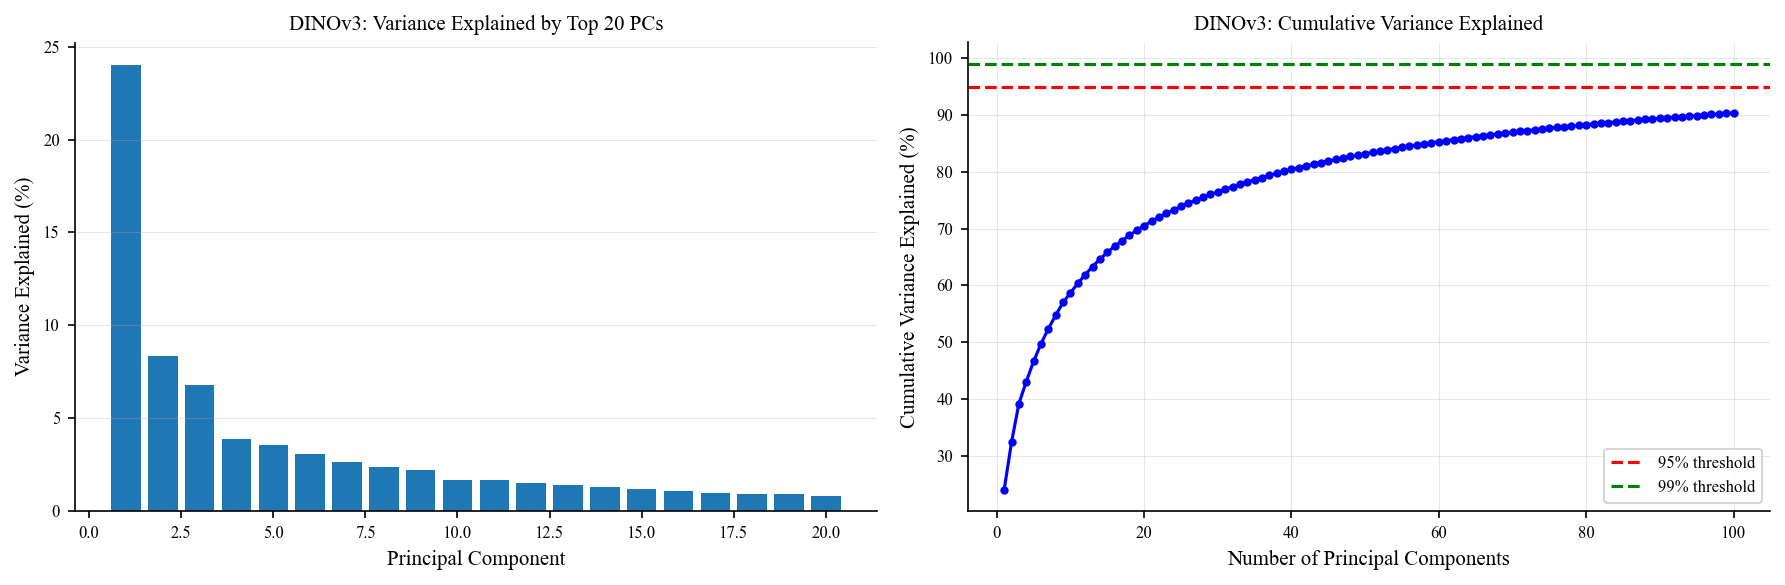


Effective dimensionality: 188 PCs for 95%, 448 PCs for 99%


In [9]:
# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Individual variance
ax = axes[0]
ax.bar(range(1, 21), pca.explained_variance_ratio_[:20] * 100)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title(f'{model_name}: Variance Explained by Top 20 PCs')
ax.grid(axis='y', alpha=0.3)

# Cumulative variance
ax = axes[1]
ax.plot(range(1, 101), cumsum[:100] * 100, 'b-o', markersize=3)
ax.axhline(y=95, color='r', linestyle='--', label='95% threshold')
ax.axhline(y=99, color='g', linestyle='--', label='99% threshold')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title(f'{model_name}: Cumulative Variance Explained')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find effective dimensionality
eff_dim_95 = np.searchsorted(cumsum, 0.95) + 1
eff_dim_99 = np.searchsorted(cumsum, 0.99) + 1
print(f"\nEffective dimensionality: {eff_dim_95} PCs for 95%, {eff_dim_99} PCs for 99%")

## Step 4 & 5: Compute PC Scores and Find Extremes

For each sample $i$, compute the PC score:
$$s_i = \langle X_c^{(i)}, v_k \rangle$$

This score tells how much image $i$ lies in the "positive" direction of PC $k$.

In [10]:
def compute_pc_scores(X_centered, pca, pc_idx):
    """
    Compute PC scores for all samples along a specific principal component.
    
    Args:
        X_centered: centered features (N, D)
        pca: fitted PCA model
        pc_idx: index of principal component (0 for PC1, 1 for PC2, etc.)
    
    Returns:
        scores: PC scores for all samples (N,)
    """
    # Get the principal component direction
    v_k = pca.components_[pc_idx]  # Shape: (D,)
    
    # Compute scores: dot product of each sample with the PC direction
    scores = X_centered @ v_k  # Shape: (N,)
    
    return scores


def get_top_bottom_k_indices(scores, k):
    """
    Get indices of top-K and bottom-K samples by PC score.
    
    Args:
        scores: PC scores for all samples (N,)
        k: number of exemplars to retrieve
    
    Returns:
        top_idx: indices of K largest scores
        bot_idx: indices of K smallest scores
    """
    sorted_idx = np.argsort(scores)
    
    bot_idx = sorted_idx[:k]  # K smallest (most negative)
    top_idx = sorted_idx[-k:][::-1]  # K largest (most positive)
    
    return top_idx, bot_idx

## Step 6: Visualize Exemplars at the Extremes

For each PC, show:
- Top-K images (highest scores) - aligned with "positive" end
- Bottom-K images (lowest scores) - aligned with "negative" end

In [20]:
def plot_exemplars(image_indices, raw_data, indices, scores, pressure, wind, title, n_cols=4):
    """
    Plot a grid of exemplar images with their metadata (lazy loading).
    
    Args:
        image_indices: list of (cyclone_idx, frame_idx) tuples
        raw_data: raw dataset for lazy loading
        indices: indices of images to plot
        scores: PC scores for the selected images
        pressure: pressure values
        wind: wind values
        title: title for the figure
        n_cols: number of columns in the grid
    """
    k = len(indices)
    n_rows = (k + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.5 * n_rows))
    axes = np.atleast_2d(axes)
    
    for i, idx in enumerate(indices):
        row, col = i // n_cols, i % n_cols
        ax = axes[row, col]
        
        # Lazy load the image
        img = get_image(raw_data, image_indices[idx])
        # if hasattr(img, 'convert'):  # PIL Image
        img = np.array(img)
        
        # Display image
        if len(img.shape) == 2:  # Grayscale
            ax.imshow(img, cmap='gray_r')
        else:
            ax.imshow(img)
        
        ax.set_title(f"Score: {scores[i]:.2f}\nP: {pressure[idx]:.0f}mb, W: {wind[idx]:.0f}kts", 
                     fontsize=9)
        ax.axis('off')
    
    # Hide empty subplots
    for i in range(k, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes[row, col].axis('off')
    
    fig.suptitle(title, fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"../figs/pca/{title.replace(' ', '_').replace('/', '_')}.pdf")
    
    return fig


def visualize_pc_extremes(X_centered, image_indices, raw_data, pressure, wind, pca, pc_idx, k=8, model_name=""):
    """
    Visualize top-K and bottom-K exemplars for a specific PC (with lazy loading).
    
    Args:
        X_centered: centered features
        image_indices: list of (cyclone_idx, frame_idx) tuples
        raw_data: raw dataset for lazy loading
        pressure: pressure values
        wind: wind values
        pca: fitted PCA model
        pc_idx: index of PC to visualize (0 for PC1)
        k: number of exemplars
        model_name: name of the model for titles
    """
    # Compute scores
    scores = compute_pc_scores(X_centered, pca, pc_idx)
    
    # Get top and bottom indices
    top_idx, bot_idx = get_top_bottom_k_indices(scores, k)
    
    # Print statistics
    var_explained = pca.explained_variance_ratio_[pc_idx] * 100
    print(f"\nPC{pc_idx + 1} ({var_explained:.2f}% variance):")
    print(f"  Score range: [{scores.min():.2f}, {scores.max():.2f}]")
    print(f"  Top-{k} scores: {scores[top_idx]}")
    print(f"  Bottom-{k} scores: {scores[bot_idx]}")
    
    # Plot top exemplars
    fig_top = plot_exemplars(
        image_indices, raw_data, top_idx, scores[top_idx], pressure, wind,
        f"{model_name} PC{pc_idx + 1} - TOP {k} (Positive Direction)\nVariance Explained: {var_explained:.2f}%"
    )
    plt.show()
    
    # Plot bottom exemplars
    fig_bot = plot_exemplars(
        image_indices, raw_data, bot_idx, scores[bot_idx], pressure, wind,
        f"{model_name} PC{pc_idx + 1} - BOTTOM {k} (Negative Direction)\nVariance Explained: {var_explained:.2f}%"
    )
    plt.show()
    
    return scores, top_idx, bot_idx

## Step 7: Analyze Top PCs on Full Dataset

Visualize exemplars for PC1 through PC5 to interpret what each dimension encodes.


Analyzing Top 1 Principal Components for DINOv3

------------------------------------------------------------

PC1 (24.02% variance):
  Score range: [-9.04, 8.07]
  Top-4 scores: [8.07496564 7.92115368 7.90456661 7.87232943]
  Bottom-4 scores: [-9.04103915 -8.91035044 -8.90173342 -8.82778742]


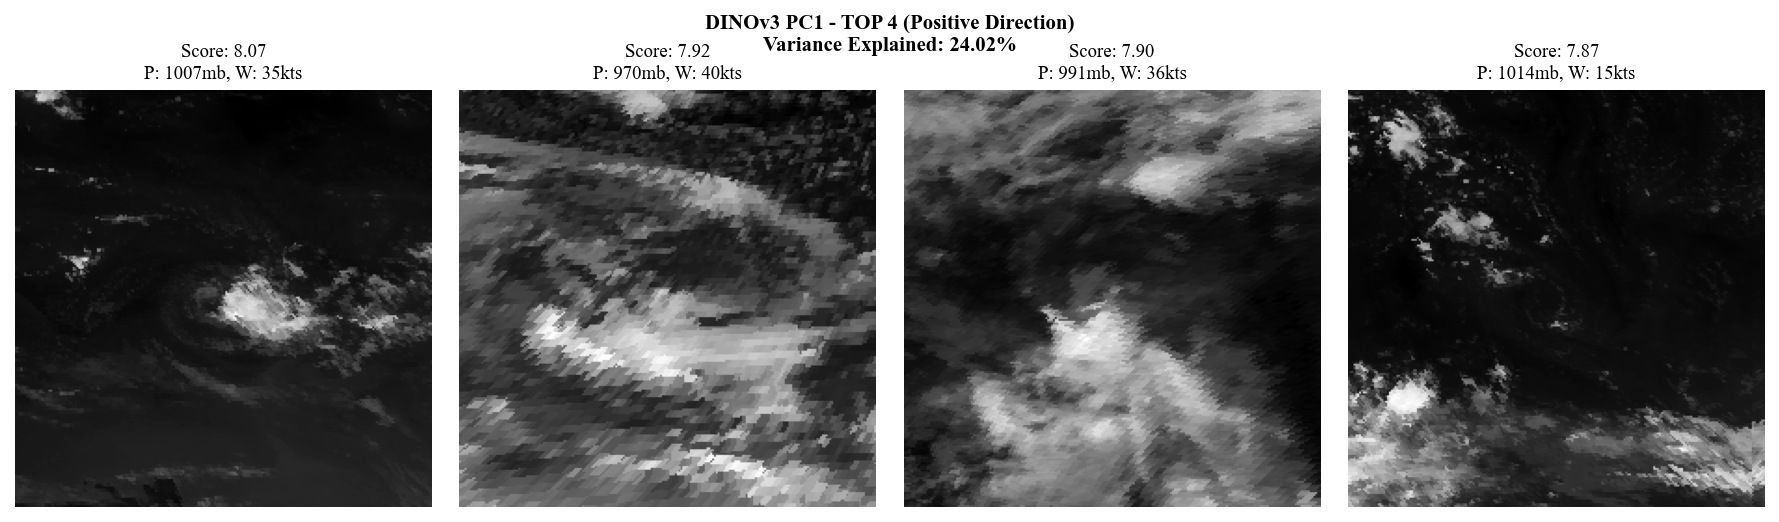

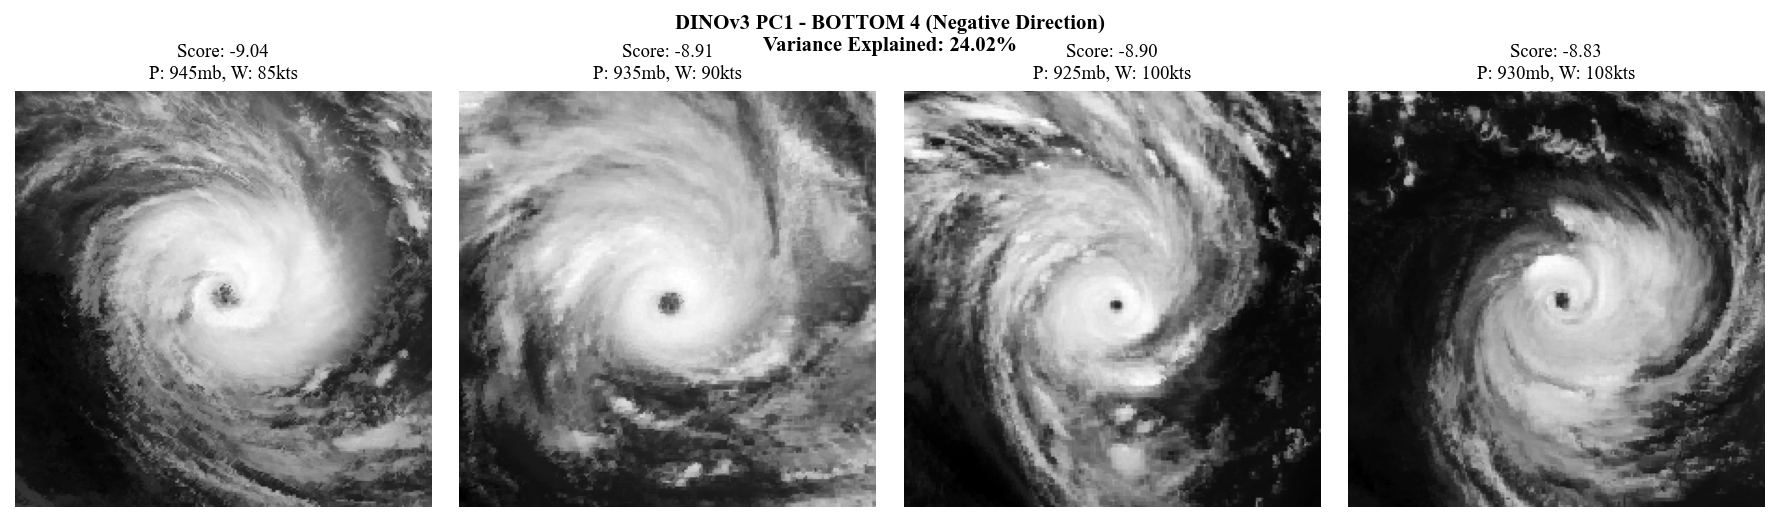

In [22]:
print(f"\n{'='*70}")
print(f"Analyzing Top {N_PCS_TO_ANALYZE} Principal Components for {model_name}")
print(f"{'='*70}")

pc_results = {}

for pc_idx in range(N_PCS_TO_ANALYZE):
    print(f"\n{'-'*60}")
    scores, top_idx, bot_idx = visualize_pc_extremes(
        X_centered, image_indices, raw_data, pressure, wind, pca, 
        pc_idx=pc_idx, k=K_EXEMPLARS, model_name=model_name
    )
    pc_results[pc_idx] = {
        'scores': scores,
        'top_idx': top_idx,
        'bot_idx': bot_idx,
    }

## Step 8: PC Score vs Intensity Correlation

Check if any PC strongly correlates with intensity (pressure/wind). If so, that PC captures "intensity" as a visual factor.

In [13]:
from scipy.stats import pearsonr, spearmanr

print(f"\n{'='*70}")
print(f"PC Score Correlation with Intensity")
print(f"{'='*70}")

correlation_data = []

for pc_idx in range(min(20, pca.n_components_)):
    scores = compute_pc_scores(X_centered, pca, pc_idx)
    
    r_pressure, p_pressure = pearsonr(scores, pressure)
    r_wind, p_wind = pearsonr(scores, wind)
    
    correlation_data.append({
        'PC': pc_idx + 1,
        'Var %': pca.explained_variance_ratio_[pc_idx] * 100,
        'r(Pressure)': r_pressure,
        'p(Pressure)': p_pressure,
        'r(Wind)': r_wind,
        'p(Wind)': p_wind,
    })

import pandas as pd
corr_df = pd.DataFrame(correlation_data)
print(corr_df.to_string(index=False))


PC Score Correlation with Intensity
 PC     Var %  r(Pressure)   p(Pressure)   r(Wind)       p(Wind)
  1 24.023733     0.603615  0.000000e+00 -0.625666  0.000000e+00
  2  8.372400     0.227916 4.221283e-144 -0.265291 2.175719e-196
  3  6.770265     0.089407  3.603809e-23 -0.023836  8.331920e-03
  4  3.895150     0.010100  2.636633e-01 -0.033427  2.152642e-04
  5  3.575308     0.040147  8.795466e-06 -0.004068  6.526053e-01
  6  3.082175    -0.077273  1.085745e-17  0.109396  6.239633e-34
  7  2.649981     0.009855  2.754112e-01 -0.058928  6.705633e-11
  8  2.399555     0.004334  6.314884e-01 -0.005751  5.244944e-01
  9  2.231985     0.101383  2.346334e-29 -0.082964  3.670516e-20
 10  1.690240     0.115971  6.002745e-38 -0.054139  2.023555e-09
 11  1.665824    -0.080813  3.304536e-19 -0.030735  6.683511e-04
 12  1.531086    -0.022796  1.163201e-02  0.041416  4.531134e-06
 13  1.429246    -0.250349 2.064823e-174  0.244466 3.744469e-166
 14  1.287744    -0.115464  1.248486e-37  0.139931  1

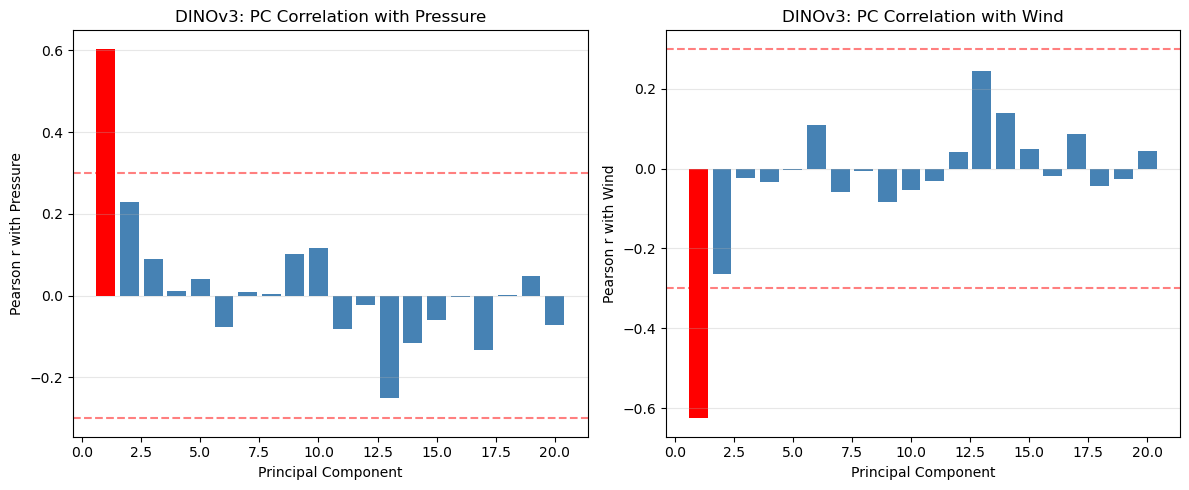


Intensity-correlated PCs (|r| > 0.3): [1]


In [16]:
# Visualize correlations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pressure correlation
ax = axes[0]
colors = ['red' if abs(r) > 0.3 else 'steelblue' for r in corr_df['r(Pressure)']]
ax.bar(corr_df['PC'], corr_df['r(Pressure)'], color=colors)
ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
ax.axhline(y=-0.3, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r with Pressure')
ax.set_title(f'{model_name}: PC Correlation with Pressure')
ax.grid(axis='y', alpha=0.3)

# Wind correlation
ax = axes[1]
colors = ['red' if abs(r) > 0.3 else 'steelblue' for r in corr_df['r(Wind)']]
ax.bar(corr_df['PC'], corr_df['r(Wind)'], color=colors)
ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
ax.axhline(y=-0.3, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r with Wind')
ax.set_title(f'{model_name}: PC Correlation with Wind')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Identify intensity-correlated PCs
intensity_pcs = corr_df[(abs(corr_df['r(Pressure)']) > 0.3) | (abs(corr_df['r(Wind)']) > 0.3)]['PC'].tolist()
print(f"\nIntensity-correlated PCs (|r| > 0.3): {intensity_pcs}")

---
## Step 9: Within-Bin PCA for extremes

To avoid "PC = intensity" confounds, repeat the analysis for all bins:
1. Fit PCA on winthin Cat features
2. Show top/bottom exemplars inside Cat

In [29]:
def extract_bin_data(X, image_indices, pressure, wind, cyclone_ids, low, high):
    """Extract data for a specific pressure bin (with lazy loading support)."""
    mask = (pressure >= low) & (pressure < high)
    
    X_bin = X[mask]
    image_indices_bin = [image_indices[i] for i in range(len(image_indices)) if mask[i]]
    pressure_bin = pressure[mask]
    wind_bin = wind[mask]
    cyclone_ids_bin = [cyclone_ids[i] for i in range(len(cyclone_ids)) if mask[i]]
    
    return X_bin, image_indices_bin, pressure_bin, wind_bin, cyclone_ids_bin, mask


# Extract Cat 5 data
print(f"\n{'='*70}")
print(f"Within-Bin PCA Analysis: pressure < {CAT5_PRESSURE_THRESHOLD} mb")
print(f"{'='*70}")

X_cat5, image_indices_cat5, pressure_cat5, wind_cat5, cyclone_ids_cat5, cat5_mask = extract_bin_data(
    X, image_indices, pressure, wind, cyclone_ids, 0, CAT5_PRESSURE_THRESHOLD
)

print(f"\n data:")
print(f"  Samples: {len(X_cat5)} ({100*len(X_cat5)/len(X):.2f}% of total)")
print(f"  Pressure range: [{pressure_cat5.min():.1f}, {pressure_cat5.max():.1f}] mb")
print(f"  Wind range: [{wind_cat5.min():.1f}, {wind_cat5.max():.1f}] kts")


Within-Bin PCA Analysis: pressure < 980 mb

 data:
  Samples: 2630 (21.47% of total)
  Pressure range: [895.0, 979.0] mb
  Wind range: [40.0, 160.0] kts


In [30]:
# Center Cat 5 features (using Cat 5 mean)
X_cat5_centered, X_cat5_mean = center_features(X_cat5)

# Fit PCA on Cat 5 only
pca_cat5 = fit_pca(X_cat5_centered)

print(f"\nPCA fitted on Cat 5 with {pca_cat5.n_components_} components")
print(f"\nVariance explained by top PCs (Cat 5 only):")
cumsum_cat5 = np.cumsum(pca_cat5.explained_variance_ratio_)
for i in range(min(10, len(cumsum_cat5))):
    print(f"  PC{i+1}: {pca_cat5.explained_variance_ratio_[i]*100:.2f}% (cumulative: {cumsum_cat5[i]*100:.2f}%)")


PCA fitted on Cat 5 with 768 components

Variance explained by top PCs (Cat 5 only):
  PC1: 22.71% (cumulative: 22.71%)
  PC2: 10.00% (cumulative: 32.71%)
  PC3: 8.39% (cumulative: 41.10%)
  PC4: 4.37% (cumulative: 45.46%)
  PC5: 3.34% (cumulative: 48.80%)
  PC6: 2.89% (cumulative: 51.69%)
  PC7: 2.52% (cumulative: 54.21%)
  PC8: 2.28% (cumulative: 56.50%)
  PC9: 2.07% (cumulative: 58.56%)
  PC10: 1.86% (cumulative: 60.43%)



Top 1 Principal Components WITHIN Cat 5

------------------------------------------------------------

PC1 (22.71% variance):
  Score range: [-5.52, 11.36]
  Top-4 scores: [11.35641149 11.11269301 11.08843076 10.91680135]
  Bottom-4 scores: [-5.52414785 -5.43718519 -5.39706684 -5.35199177]


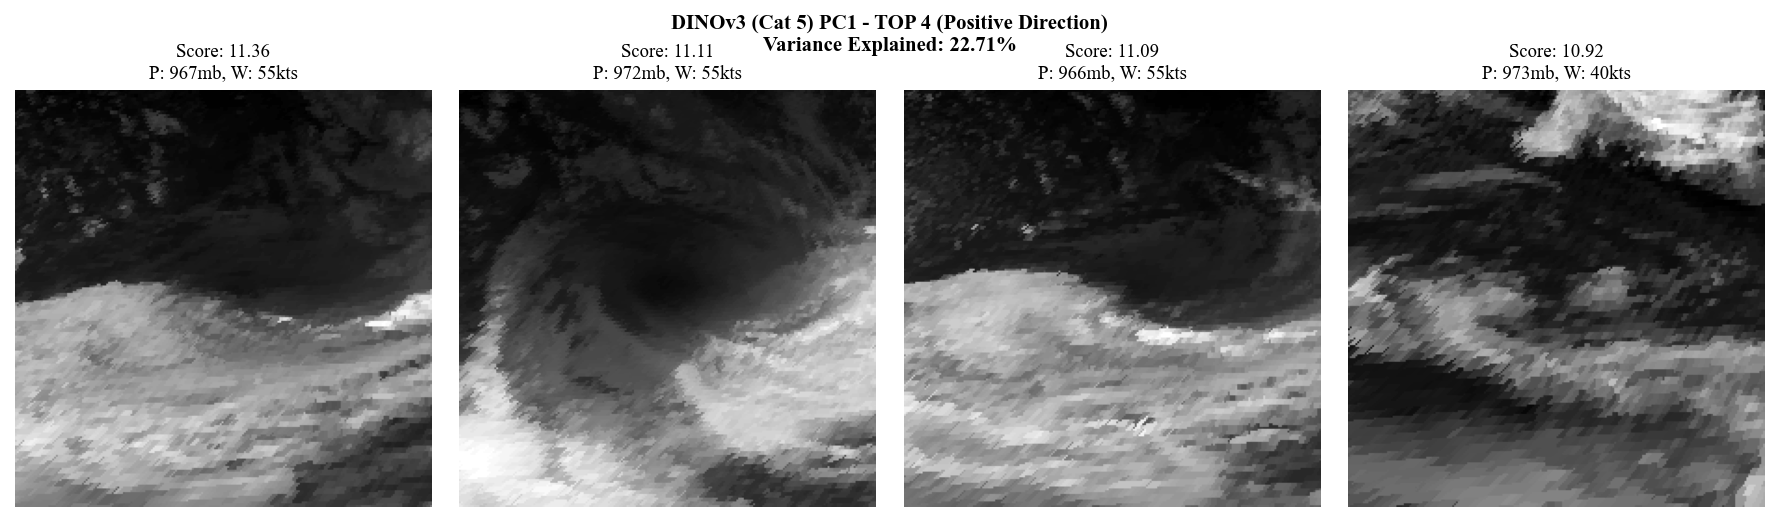

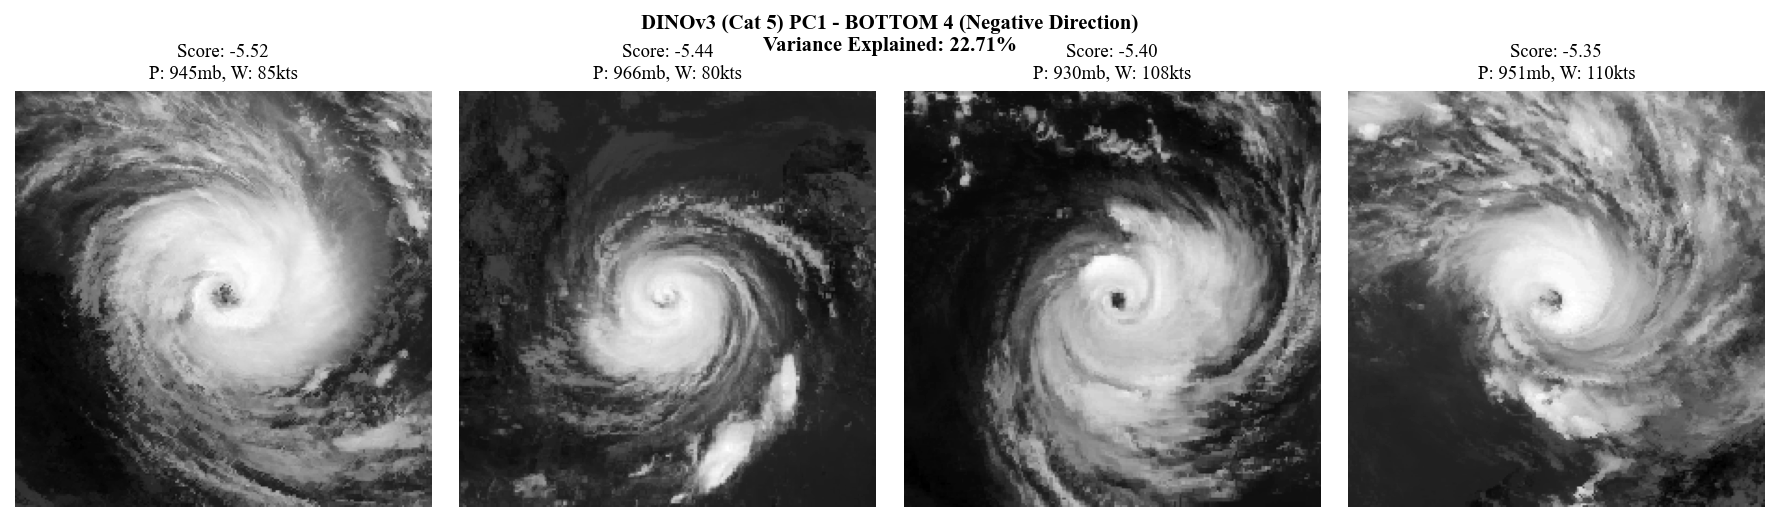

In [31]:
# Analyze top PCs within Cat 5
print(f"\n{'='*70}")
print(f"Top {N_PCS_TO_ANALYZE} Principal Components WITHIN Cat 5")
print(f"{'='*70}")

pc_results_cat5 = {}

for pc_idx in range(N_PCS_TO_ANALYZE):
    print(f"\n{'-'*60}")
    scores, top_idx, bot_idx = visualize_pc_extremes(
        X_cat5_centered, image_indices_cat5, raw_data, pressure_cat5, wind_cat5, pca_cat5,
        pc_idx=pc_idx, k=K_EXEMPLARS, model_name=f"{model_name} (Cat 5)"
    )
    pc_results_cat5[pc_idx] = {
        'scores': scores,
        'top_idx': top_idx,
        'bot_idx': bot_idx,
    }

In [27]:
# Check correlation with intensity within Cat 5
print(f"\n{'='*70}")
print(f"PC Score Correlation with Intensity (Cat 5 Only)")
print(f"{'='*70}")

correlation_data_cat5 = []

for pc_idx in range(min(20, pca_cat5.n_components_)):
    scores = compute_pc_scores(X_cat5_centered, pca_cat5, pc_idx)
    
    r_pressure, p_pressure = pearsonr(scores, pressure_cat5)
    r_wind, p_wind = pearsonr(scores, wind_cat5)
    
    correlation_data_cat5.append({
        'PC': pc_idx + 1,
        'Var %': pca_cat5.explained_variance_ratio_[pc_idx] * 100,
        'r(Pressure)': r_pressure,
        'p(Pressure)': p_pressure,
        'r(Wind)': r_wind,
        'p(Wind)': p_wind,
    })

corr_df_cat5 = pd.DataFrame(correlation_data_cat5)
print(corr_df_cat5.to_string(index=False))


PC Score Correlation with Intensity (Cat 5 Only)
 PC     Var %  r(Pressure)  p(Pressure)   r(Wind)      p(Wind)
  1 22.471984     0.057376     0.652473  0.408612 8.020690e-04
  2 16.654388     0.334194     0.006956 -0.194069 1.243903e-01
  3  7.950283    -0.104748     0.410087 -0.617038 5.641521e-08
  4  5.956114    -0.115793     0.362213 -0.251057 4.538767e-02
  5  4.738713     0.068952     0.588239  0.002455 9.846407e-01
  6  4.033181    -0.001212     0.992414  0.102912 4.183883e-01
  7  3.825282    -0.116983     0.357269  0.028687 8.219665e-01
  8  3.247221    -0.025307     0.842658  0.103608 4.152315e-01
  9  2.678340     0.485872     0.000047 -0.237551 5.874415e-02
 10  2.124946     0.046729     0.713870  0.084010 5.092541e-01
 11  1.945642    -0.317504     0.010573 -0.064366 6.133437e-01
 12  1.682602     0.158137     0.212020 -0.076861 5.460695e-01
 13  1.624787     0.244351     0.051668 -0.025927 8.388492e-01
 14  1.460526    -0.012843     0.919767  0.110281 3.856640e-01
 15  

In [ ]:
# Visualize correlations for Cat 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pressure correlation
ax = axes[0]
colors = ['red' if abs(r) > 0.3 else 'steelblue' for r in corr_df_cat5['r(Pressure)']]
ax.bar(corr_df_cat5['PC'], corr_df_cat5['r(Pressure)'], color=colors)
ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
ax.axhline(y=-0.3, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r with Pressure')
ax.set_title(f'{model_name} (Cat 5): PC Correlation with Pressure')
ax.grid(axis='y', alpha=0.3)

# Wind correlation
ax = axes[1]
colors = ['red' if abs(r) > 0.3 else 'steelblue' for r in corr_df_cat5['r(Wind)']]
ax.bar(corr_df_cat5['PC'], corr_df_cat5['r(Wind)'], color=colors)
ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
ax.axhline(y=-0.3, color='r', linestyle='--', alpha=0.5)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Pearson r with Wind')
ax.set_title(f'{model_name} (Cat 5): PC Correlation with Wind')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Identify intensity-correlated PCs within Cat 5
intensity_pcs_cat5 = corr_df_cat5[(abs(corr_df_cat5['r(Pressure)']) > 0.3) | (abs(corr_df_cat5['r(Wind)']) > 0.3)]['PC'].tolist()
print(f"\nIntensity-correlated PCs within Cat 5 (|r| > 0.3): {intensity_pcs_cat5}")

---
## Step 10: Compare All Models

Repeat the analysis for all VFMs to compare what each model encodes.

In [ ]:
def analyze_model_pcs(model_config, raw_dataset_path, n_pcs=5, k_exemplars=8, split='test'):
    """Full PCA exemplar analysis for a model (memory-efficient with lazy loading)."""
    model_name = model_config["name"]
    
    print(f"\n{'='*70}")
    print(f"Analyzing: {model_name}")
    print(f"{'='*70}")
    
    # Load data (lazy loading for images)
    X, image_indices, pressure, wind, cyclone_ids, raw_data = load_features_and_images(
        Path(model_config["feature_dataset"]),
        Path(raw_dataset_path),
        split=split
    )
    
    # Center and fit PCA
    X_centered, X_mean = center_features(X)
    pca = fit_pca(X_centered)
    
    # Compute correlations
    correlations = []
    for pc_idx in range(min(20, pca.n_components_)):
        scores = compute_pc_scores(X_centered, pca, pc_idx)
        r_pressure, _ = pearsonr(scores, pressure)
        r_wind, _ = pearsonr(scores, wind)
        correlations.append({
            'PC': pc_idx + 1,
            'Var %': pca.explained_variance_ratio_[pc_idx] * 100,
            'r(Pressure)': r_pressure,
            'r(Wind)': r_wind,
        })
    
    # Cat 5 analysis
    cat5_mask = pressure < CAT5_PRESSURE_THRESHOLD
    X_cat5 = X[cat5_mask]
    pressure_cat5 = pressure[cat5_mask]
    wind_cat5 = wind[cat5_mask]
    
    X_cat5_centered, _ = center_features(X_cat5)
    pca_cat5 = fit_pca(X_cat5_centered)
    
    correlations_cat5 = []
    for pc_idx in range(min(20, pca_cat5.n_components_)):
        scores = compute_pc_scores(X_cat5_centered, pca_cat5, pc_idx)
        r_pressure, _ = pearsonr(scores, pressure_cat5)
        r_wind, _ = pearsonr(scores, wind_cat5)
        correlations_cat5.append({
            'PC': pc_idx + 1,
            'Var %': pca_cat5.explained_variance_ratio_[pc_idx] * 100,
            'r(Pressure)': r_pressure,
            'r(Wind)': r_wind,
        })
    
    return {
        'model_name': model_name,
        'pca': pca,
        'pca_cat5': pca_cat5,
        'correlations': pd.DataFrame(correlations),
        'correlations_cat5': pd.DataFrame(correlations_cat5),
        'n_samples': len(X),
        'n_samples_cat5': len(X_cat5),
    }

In [ ]:
# Analyze all models
all_model_results = {}

for model_config in MODELS_TO_ANALYZE:
    try:
        results = analyze_model_pcs(model_config, RAW_DATASET_PATH)
        all_model_results[results['model_name']] = results
    except Exception as e:
        print(f"Error analyzing {model_config['name']}: {e}")

In [ ]:
# Compare variance explained across models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full dataset
ax = axes[0]
for model_name, results in all_model_results.items():
    cumsum = np.cumsum(results['pca'].explained_variance_ratio_[:100])
    ax.plot(range(1, len(cumsum) + 1), cumsum * 100, label=model_name, linewidth=2)
ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('All Data: Cumulative Variance Explained')
ax.legend()
ax.grid(alpha=0.3)

# Cat 5 only
ax = axes[1]
for model_name, results in all_model_results.items():
    cumsum = np.cumsum(results['pca_cat5'].explained_variance_ratio_[:100])
    ax.plot(range(1, len(cumsum) + 1), cumsum * 100, label=model_name, linewidth=2)
ax.axhline(y=95, color='gray', linestyle='--', alpha=0.5, label='95%')
ax.set_xlabel('Number of PCs')
ax.set_ylabel('Cumulative Variance Explained (%)')
ax.set_title('Cat 5 Only: Cumulative Variance Explained')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Compare intensity correlations across models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (target, target_col) in enumerate([('Pressure', 'r(Pressure)'), ('Wind', 'r(Wind)')]):
    # Full dataset
    ax = axes[i, 0]
    x = np.arange(1, 21)
    width = 0.25
    for j, (model_name, results) in enumerate(all_model_results.items()):
        corr = results['correlations'][target_col].values[:20]
        ax.bar(x + j * width, corr, width, label=model_name)
    ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=-0.3, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(f'Pearson r with {target}')
    ax.set_title(f'All Data: PC Correlation with {target}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Cat 5 only
    ax = axes[i, 1]
    for j, (model_name, results) in enumerate(all_model_results.items()):
        corr = results['correlations_cat5'][target_col].values[:20]
        ax.bar(x + j * width, corr, width, label=model_name)
    ax.axhline(y=0.3, color='r', linestyle='--', alpha=0.5)
    ax.axhline(y=-0.3, color='r', linestyle='--', alpha=0.5)
    ax.set_xlabel('Principal Component')
    ax.set_ylabel(f'Pearson r with {target}')
    ax.set_title(f'Cat 5 Only: PC Correlation with {target}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Summary: Interpretation Guide

### Reading the Exemplar Grids

For each PC, compare the Top-K and Bottom-K grids:

| Visual Pattern | Interpretation |
|----------------|----------------|
| Top: clear eye, Bottom: no eye | PC encodes "eye-ness" |
| Top: symmetric rings, Bottom: messy clouds | PC encodes "ring symmetry" |
| Top: sharp textures, Bottom: smooth | PC encodes "texture/contrast" |
| Top: high intensity, Bottom: low intensity | PC encodes "intensity" (expected for top PCs on full data) |
| Top: specific basin/sensor, Bottom: different | PC encodes nuisance factor |

### Key Questions Answered

1. **Do top PCs correlate with intensity?**
   - Check the correlation bar charts
   - High |r| means PC captures intensity-related visual features

2. **What varies within Cat 5?**
   - Within-bin PCA removes intensity confound
   - Remaining PCs show nuisance factors or fine-grained intensity signals

3. **Are representations label-relevant?**
   - If top PCs show eye structure, convection patterns → label-relevant
   - If top PCs show sensor artifacts, geographic patterns → nuisance-dominated

In [ ]:
# Final summary table
print("\n" + "="*80)
print("SUMMARY: Effective Dimensionality and Intensity Correlation")
print("="*80)

summary_data = []
for model_name, results in all_model_results.items():
    pca = results['pca']
    pca_cat5 = results['pca_cat5']
    
    cumsum = np.cumsum(pca.explained_variance_ratio_)
    cumsum_cat5 = np.cumsum(pca_cat5.explained_variance_ratio_)
    
    # Find PCs with |r| > 0.3 for pressure
    intensity_pcs = results['correlations'][abs(results['correlations']['r(Pressure)']) > 0.3]['PC'].tolist()
    intensity_pcs_cat5 = results['correlations_cat5'][abs(results['correlations_cat5']['r(Pressure)']) > 0.3]['PC'].tolist()
    
    summary_data.append({
        'Model': model_name,
        'N (all)': results['n_samples'],
        'N (Cat5)': results['n_samples_cat5'],
        'Eff Dim 95% (all)': np.searchsorted(cumsum, 0.95) + 1,
        'Eff Dim 95% (Cat5)': np.searchsorted(cumsum_cat5, 0.95) + 1,
        'Intensity PCs (all)': str(intensity_pcs[:5]) if intensity_pcs else 'None',
        'Intensity PCs (Cat5)': str(intensity_pcs_cat5[:5]) if intensity_pcs_cat5 else 'None',
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))